In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
data = pd.read_csv('../data/data_globant_cleaned.csv')

In [15]:
engagement_groups = data["Engagement Group"]

In [16]:
import numpy as np

x = np.asarray(engagement_groups).astype(int)   # serie temporal
max_state = x.max()
min_state = x.min()
states = np.arange(min_state, max_state+1)
k = len(states)

# mapeo por si min_state != 0
idx = {s:i for i,s in enumerate(states)}

P = np.zeros((k,k))

for i in range(len(x)-1):
    a = idx[x[i]]
    b = idx[x[i+1]]
    P[a,b] += 1

row_sums = P.sum(axis=1, keepdims=True)
P_norm = np.divide(P, row_sums, out=np.zeros_like(P), where=row_sums!=0)

print("Matriz de transición:")
print(P_norm)
print("Suma por fila:", P_norm.sum(axis=1))

Matriz de transición:
[[0.29850746 0.30597015 0.09328358 0.15671642 0.09328358 0.05223881]
 [0.03173204 0.70956368 0.15601587 0.05156457 0.02335831 0.02776554]
 [0.01372998 0.16979405 0.51075515 0.20045767 0.10251716 0.002746  ]
 [0.01780944 0.05387355 0.21059662 0.41941229 0.24487979 0.05342832]
 [0.01193208 0.0192749  0.09729234 0.27122533 0.40844424 0.19183112]
 [0.00901713 0.01938683 0.00270514 0.05184851 0.19702435 0.72001803]]
Suma por fila: [1. 1. 1. 1. 1. 1.]


In [17]:
from pgmpy.models import MarkovChain


model = MarkovChain(["eng"], [6])   # 0..5 -> card=6
model.add_transition_model("eng", P_norm)

In [18]:
import numpy as np

k = len(states)
pi0 = np.zeros(k)
pi0[idx[3]] = 1.0   # estado inicial = 3

n = 1  # pasos adelante
P_n = np.linalg.matrix_power(P_norm, n)
pi_n = pi0 @ P_n    # distribución después de n pasos

print("Distribución después de", n, "pasos:")
for s, p in zip(states, pi_n):
    print(f"  P(X_{n} = {s}) = {p:.4f}")

Distribución después de 1 pasos:
  P(X_1 = 0) = 0.0178
  P(X_1 = 1) = 0.0539
  P(X_1 = 2) = 0.2106
  P(X_1 = 3) = 0.4194
  P(X_1 = 4) = 0.2449
  P(X_1 = 5) = 0.0534


In [19]:
def transition_matrix_for_subset(df, mask, col_eng='Engagement Group', n_states=6):
    sub = df[mask].sort_values(['Name','Date'])
    x = sub[col_eng].to_numpy().astype(int)
    P_counts = np.zeros((n_states, n_states))
    for i in range(len(x)-1):
        a, b = x[i], x[i+1]
        P_counts[a,b] += 1
    row_sums = P_counts.sum(axis=1, keepdims=True)
    P = np.divide(P_counts, row_sums, out=np.zeros_like(P_counts), where=row_sums!=0)
    return P

def prob_mejorar(P):
    total = 0
    for i in range(P.shape[0]):
        total += np.sum(P[i, i+1:])
    return total / P.shape[0]

def prob_empeorar(P):
    total = 0
    for i in range(P.shape[0]):
        total += np.sum(P[i, :i])
    return total / P.shape[0]

def estacionaria(P):
    vals, vecs = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(vals - 1))
    pi = np.real(vecs[:, idx])
    pi = pi / pi.sum()
    return pi

In [20]:
P_proyA = transition_matrix_for_subset(data, data['Project Tag']=='CATPRO')
P_proyB = transition_matrix_for_subset(data, data['Project Tag']=='NEXDEV')

In [21]:
print("CATPRO:\n", np.round(P_proyA,3))
print("NEXDEV:\n", np.round(P_proyB,3))

CATPRO:
 [[0.277 0.319 0.021 0.191 0.106 0.085]
 [0.024 0.715 0.154 0.048 0.042 0.018]
 [0.011 0.199 0.481 0.177 0.126 0.005]
 [0.024 0.058 0.18  0.336 0.331 0.072]
 [0.007 0.034 0.067 0.252 0.429 0.212]
 [0.007 0.022 0.002 0.067 0.207 0.695]]
NEXDEV:
 [[0.344 0.295 0.098 0.082 0.148 0.033]
 [0.037 0.608 0.136 0.064 0.075 0.08 ]
 [0.005 0.143 0.544 0.185 0.124 0.   ]
 [0.025 0.048 0.202 0.345 0.308 0.073]
 [0.016 0.044 0.075 0.231 0.4   0.234]
 [0.006 0.043 0.    0.077 0.279 0.596]]


In [22]:
print("Probabilidad de mejorar en CATPRO:", prob_mejorar(P_proyA))
print("Probabilidad de mejorar en NEXDEV:", prob_mejorar(P_proyB))

print("Probabilidad de empeorar en CATPRO:", prob_empeorar(P_proyA))
print("Probabilidad de empeorar en NEXDEV:", prob_empeorar(P_proyB))

Probabilidad de mejorar en CATPRO: 0.31807468139353084
Probabilidad de mejorar en NEXDEV: 0.32238194876255283
Probabilidad de empeorar en CATPRO: 0.19326830008780208
Probabilidad de empeorar en NEXDEV: 0.20484785613391399


In [23]:
pi_A = estacionaria(P_proyA)
pi_B = estacionaria(P_proyB)

print("Estacionaria CATPRO:", np.round(pi_A,3))
print("Estacionaria NEXDEV:", np.round(pi_B,3))

Estacionaria CATPRO: [0.019 0.206 0.152 0.171 0.231 0.221]
Estacionaria NEXDEV: [0.025 0.155 0.174 0.181 0.253 0.212]


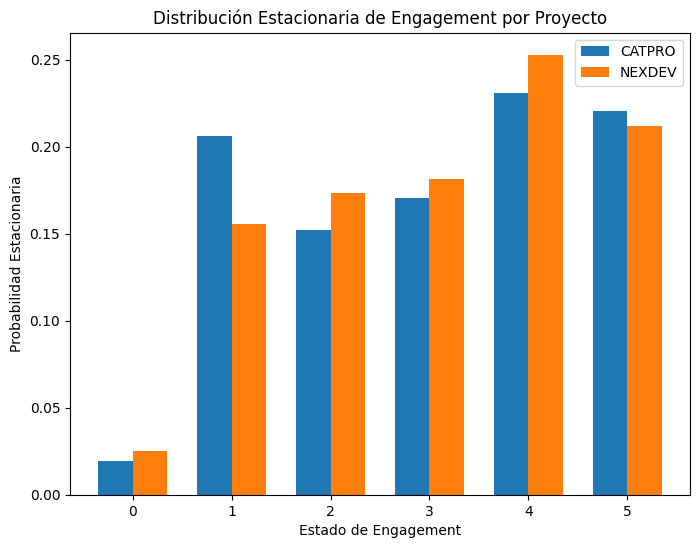

In [24]:
plt.figure(figsize=(8, 6))
states = np.arange(P_proyA.shape[0])
width = 0.35
plt.bar(states - width/2, pi_A, width=width, label='CATPRO')
plt.bar(states + width/2, pi_B, width=width, label='NEXDEV')
plt.xlabel('Estado de Engagement')
plt.ylabel('Probabilidad Estacionaria')
plt.title('Distribución Estacionaria de Engagement por Proyecto')
plt.xticks(states)
plt.legend()
plt.show()

In [25]:
proj_vals = data['Project Tag'].unique()
loc_vals  = data['Location'].unique()
pos_vals  = data['Position'].unique()

transition_matrices = {}  # dict: (proj, loc, pos) -> matriz P

for p in proj_vals:
    for l in loc_vals:
        for s in pos_vals:
            mask = (
                (data['Project Tag'] == p) &
                (data['Location']    == l) &
                (data['Position']    == s)
            )
            # Necesitas al menos 2 observaciones para tener transiciones
            if mask.sum() < 2:
                continue
            
            P = transition_matrix_for_subset(data, mask)
            transition_matrices[(p, l, s)] = P

len(transition_matrices)

78

In [ ]:
transition_matrices[("CATPRO","MX/JALISCO/GDL","Business Analyst")]

KeyError: ('CATPRO', 'MX/JALISCO/GDL', 'Software Developer')

In [27]:
mask = (
    (data['Project Tag'] == "CATPRO") &
    (data['Location'] == "MX/JALISCO/GDL") &
    (data['Position'] == "Business Analyst")
)

sub = data[mask].sort_values(['Name', 'Date'])
sub['Engagement Group'].value_counts()

Engagement Group
5    38
Name: count, dtype: int64

In [31]:
combos = (
    data
    .groupby(["Project Tag", "Location", "Position"])
    .size()
    .reset_index(name="count")
)

# Filtrar solo combinaciones con al menos 2 registros (necesario para transiciones)
combos_validas = combos[combos["count"] >= 2]

# Mostrar cuántas son
print(len(combos_validas))

# Mostrar las combinaciones reales
combos_validas

78


,Project Tag,Location,Position,count
0,ATLINT,AR/CABA/BA,Project Manager,20
1,ATLINT,AR/CABA/BA,Software Developer,268
2,ATLINT,CL/RM/SCL,Quality Assurance Tester,129
3,ATLINT,CL/RM/SCL,Software Developer,134
4,ATLINT,CO/ANT/MED,Software Developer,116
...,...,...,...,...
74,VGRDIN,CO/CUN/BOG,Business Analyst,126
75,VGRDIN,CO/CUN/BOG,Data Analyst,35
76,VGRDIN,CO/CUN/BOG,Project Manager,131
77,VGRDIN,CO/CUN/BOG,Software Developer,378
